# Exploratory Data Analysis
## Attrition Dataset

In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
with open('../data/attrition_dataset.pkl', 'rb') as f:
    df = pd.read_pickle('../data/attrition_dataset.pkl')

print(f'Shape: {df.shape}')
df.head()

Shape: (1426, 31)


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1,7.315971,13,2.0,4,3.0,2.0,4.0,31.0,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,NaN,0.0,Y,23,8,1,6.0,3,5,1,4
6,6.450877,17,3.0,4,1.0,3.0,1.0,28.0,Yes,Travel_Rarely,Research & Development,11,2,Medical,1,7,Male,2,Sales Executive,Single,58130.0,2.0,Y,20,8,1,5.0,2,0,0,0
13,8.871421,14,2.0,3,1.0,2.0,2.0,47.0,Yes,Non-Travel,Research & Development,1,1,Medical,1,14,Male,1,Research Scientist,Married,57620.0,1.0,Y,11,8,2,10.0,4,10,9,9
28,10.713066,6,2.0,3,4.0,3.0,1.0,44.0,Yes,Travel_Frequently,Research & Development,1,2,Medical,1,29,Male,2,Research Scientist,Divorced,103330.0,3.0,Y,14,8,1,19.0,2,1,0,0
30,9.662808,11,2.0,3,1.0,2.0,3.0,26.0,Yes,Travel_Rarely,Research & Development,4,3,Medical,1,31,Male,3,Research Scientist,Divorced,68540.0,2.0,Y,11,8,0,5.0,5,3,0,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1426 entries, 1 to 3786
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hrs                      1426 non-null   float64
 1   absences                 1426 non-null   int64  
 2   JobInvolvement           1279 non-null   float64
 3   PerformanceRating        1426 non-null   int64  
 4   EnvironmentSatisfaction  1418 non-null   float64
 5   JobSatisfaction          1267 non-null   float64
 6   WorkLifeBalance          1419 non-null   float64
 7   Age                      1292 non-null   float64
 8   Attrition                1426 non-null   object 
 9   BusinessTravel           1426 non-null   object 
 10  Department               1426 non-null   object 
 11  DistanceFromHome         1426 non-null   int64  
 12  Education                1426 non-null   int64  
 13  EducationField           1426 non-null   object 
 14  EmployeeCount            1426

In [5]:
df.describe()

,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,1426.000000,1426.000000,1279.000000,1426.000000,1418.000000,1267.000000,1419.000000,1292.000000,1426.000000,1426.000000,1426.0,1426.000000,1426.000000,1293.000000,1420.000000,1426.000000,1426.0,1426.000000,1424.000000,1426.000000,1426.000000,1426.000000,1426.000000
mean,7.622009,12.596774,2.722439,3.156381,2.672073,2.658248,2.711769,35.427245,9.367461,2.908135,1.0,2187.990884,2.096774,63568.437742,2.805634,15.256662,8.0,0.767882,10.048455,2.742637,6.284011,2.013324,3.615708
std,1.439585,5.506943,0.756022,0.363344,1.131606,1.092492,0.758178,9.330001,8.016363,1.009070,0.0,1279.551636,1.120352,46313.904737,2.557631,3.701689,0.0,0.832738,7.623228,1.266726,6.149938,3.125307,3.507326
min,5.465741,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.0,2.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.438629,8.000000,2.000000,3.000000,2.000000,2.000000,2.000000,29.000000,2.000000,2.000000,1.0,1069.750000,1.000000,28530.000000,1.000000,12.000000,8.0,0.000000,5.000000,2.000000,2.000000,0.000000,0.000000
50%,7.322339,13.000000,3.000000,3.000000,3.000000,3.000000,3.000000,34.000000,7.000000,3.000000,1.0,2125.000000,2.000000,48210.000000,2.000000,14.000000,8.0,1.000000,9.000000,3.000000,5.000000,1.000000,2.000000
75%,8.660602,17.000000,3.000000,3.000000,4.000000,4.000000,3.000000,41.000000,15.000000,4.000000,1.0,3335.000000,3.000000,76440.000000,4.000000,18.000000,8.0,1.000000,13.000000,3.000000,9.000000,2.000000,7.000000
max,10.937261,23.000000,4.000000,4.000000,4.000000,4.000000,4.000000,60.000000,29.000000,5.000000,1.0,4409.000000,5.000000,198590.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

JobInvolvement             147
EnvironmentSatisfaction      8
JobSatisfaction            159
WorkLifeBalance              7
Age                        134
MonthlyIncome              133
NumCompaniesWorked           6
TotalWorkingYears            2
dtype: int64

## 1. Variable Objetivo — Attrition

In [ ]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Distribución de Attrition:")
print(pd.DataFrame({'count': attrition_counts, '%': attrition_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Conteo de Attrition')
axes[0].set_ylabel('Cantidad de empleados')
for i, (label, val) in enumerate(attrition_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de Attrition')

plt.tight_layout()
plt.show()

## 2. Variables con Baja o Nula Variabilidad

Se analizan las variables que podrían no aportar información predictiva.

Valores únicos por variable:

EmployeeCount                 1
Over18                        1
StandardHours                 1
PerformanceRating             2
Attrition                     2
Gender                        2
BusinessTravel                3
Department                    3
MaritalStatus                 3
JobInvolvement                4
JobSatisfaction               4
StockOptionLevel              4
WorkLifeBalance               4
EnvironmentSatisfaction       4
JobLevel                      5
Education                     5
EducationField                6
TrainingTimesLastYear         7
JobRole                       9
NumCompaniesWorked           10
PercentSalaryHike            15
YearsSinceLastPromotion      16
YearsWithCurrManager         18
absences                     23
DistanceFromHome             29
YearsAtCompany               35
TotalWorkingYears            40
Age                          43
MonthlyIncome               684
hrs                        1350
EmployeeID

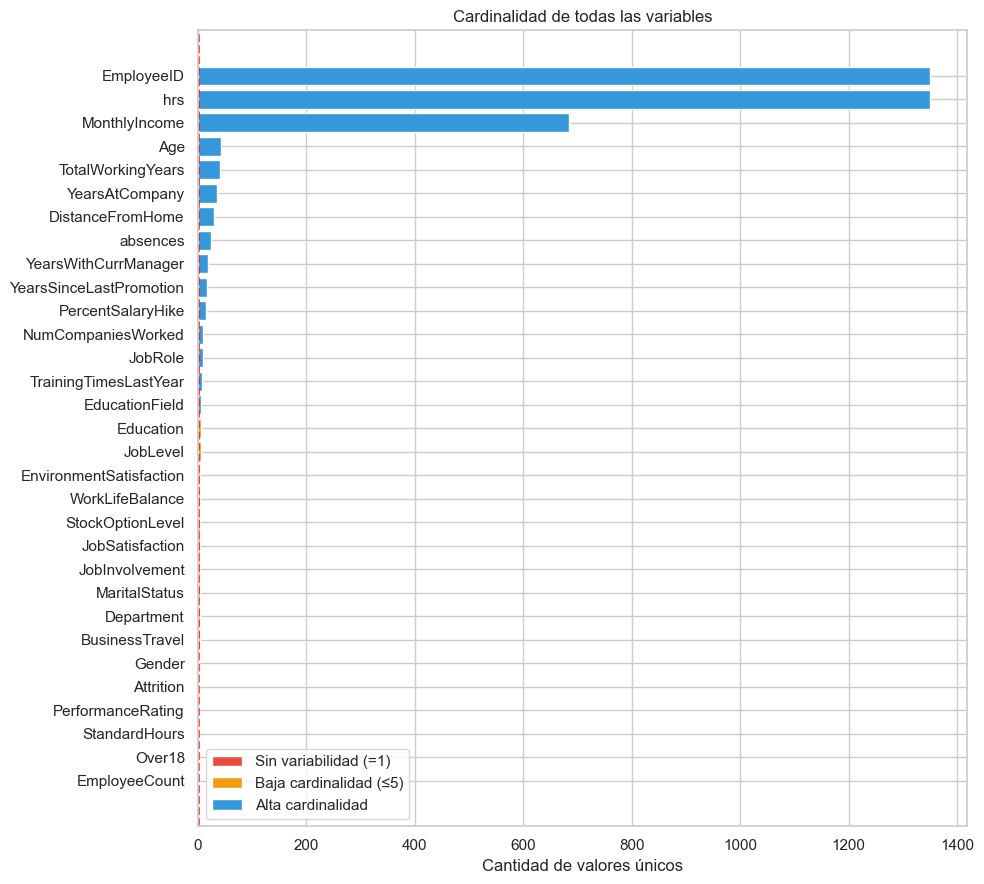


Variables con un único valor: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: [1]
  Over18: ['Y']
  StandardHours: [8]


In [34]:
unique_counts = df.nunique().sort_values()
print("Valores únicos por variable:\n")
print(unique_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if v == 1 else '#f39c12' if v <= 5 else '#3498db' for v in unique_counts.values]
ax.barh(unique_counts.index, unique_counts.values, color=colors)
ax.set_xlabel('Cantidad de valores únicos')
ax.set_title('Cardinalidad de todas las variables')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Sin variabilidad (n=1)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Sin variabilidad (=1)'),
                   Patch(facecolor='#f39c12', label='Baja cardinalidad (≤5)'),
                   Patch(facecolor='#3498db', label='Alta cardinalidad')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

# Distribución de las variables sin variabilidad
zero_var = unique_counts[unique_counts == 1].index.tolist()
print(f"\nVariables con un único valor: {zero_var}")
for col in zero_var:
    print(f"  {col}: {df[col].unique()}")

## 3. Variables Numéricas

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Variables numéricas ({len(num_cols)}): {num_cols}')

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        data = df[df['Attrition'] == label][col].dropna()
        axes[i].hist(data, bins=20, alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por Attrition', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Variables Categóricas

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.drop('Attrition').tolist()
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
    ct[['No', 'Yes']].plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
                            edgecolor='white', width=0.7)
    axes[i].set_title(f'Attrition por {col}')
    axes[i].set_ylabel('% empleados')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de Attrition por variable categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlación entre Variables Numéricas

In [ ]:
df_corr = df[num_cols].copy()
df_corr['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre variables numéricas (incluye Attrition)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Valores Faltantes

In [ ]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing.index, missing.values, color='#e67e22')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de nulos por variable')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.6, label='Umbral 10%')
ax.legend()
for bar, val in zip(bars, missing.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Outliers en Variables Numéricas

In [ ]:
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Attrition', ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(color='#2c3e50'),
               capprops=dict(color='#2c3e50'),
               flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#e74c3c'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución y outliers por variable numérica según Attrition', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlación con el Target

In [ ]:
target = (df['Attrition'] == 'Yes').astype(int)
corr_target = df[num_cols].corrwith(target).sort_values()

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con Attrition (punto-biserial)')
ax.set_title('Correlación de variables numéricas con el target')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Correlación positiva (más Attrition)'),
                   Patch(facecolor='#2ecc71', label='Correlación negativa (menos Attrition)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor correlación absoluta con Attrition:")
print(corr_target.abs().sort_values(ascending=False).head(5).to_string())

## 9. Distribución de las Variables más Correlacionadas con el Target

El punto 8 indica *cuánto* se relaciona cada variable con Attrition. Acá se profundiza en *cómo* se distribuyen las top variables, analizando medianas, dispersión y outliers para cada grupo.

In [ ]:
top_vars = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"Top 6 variables por correlación absoluta con Attrition: {top_vars}")

df_plot = df.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = {'No': '#2ecc71', 'Yes': '#e74c3c'}

for i, col in enumerate(top_vars):
    sns.boxplot(data=df_plot, x='Attrition', y=col, ax=axes[i],
                palette=palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

    medians = df_plot.groupby('Attrition')[col].median()
    for j, (label, med) in enumerate(medians.items()):
        axes[i].text(j, med, f' {med:.0f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribución de top variables correlacionadas con Attrition', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Conclusiones del EDA

### Target
- Dataset **perfectamente balanceado** (50.1% No / 49.9% Yes). No se requieren técnicas de balanceo de clases.

### Variables a descartar en preprocesamiento
- `EmployeeCount`, `StandardHours`, `Over18`: sin variabilidad, valor constante en todos los registros.
- `EmployeeID`: identificador único sin valor predictivo.

### Valores faltantes
- 8 variables presentan nulos. Las más afectadas: `JobSatisfaction` (~11%), `JobInvolvement` (~10%), `Age` (~9%), `MonthlyIncome` (~9%).
- Ninguna supera el 15%, por lo que la imputación es viable sin descartar columnas.
- Una alternativa más sofisticada sería imputación por **KNN**: buscar registros similares y asignarle el valor del vecino más cercano, preservando mejor la estructura del dato. Sin embargo, dado el tiempo y la complejidad que requiere, **se optará por imputación con la mediana**, que es robusta ante outliers y suficiente para este contexto.

### Variables más relevantes para el modelo
Según la correlación punto-biserial con Attrition:
- **Correlación negativa** (más valor → menos Attrition): `TotalWorkingYears`, `YearsWithCurrManager`, `Age`, `YearsAtCompany` — empleados con más experiencia y antigüedad tienden a quedarse.
- **Correlación positiva** (más valor → más Attrition): `hrs` — empleados con más horas trabajadas muestran mayor rotación.
- Las variables de **satisfacción** (`JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`) también muestran correlación negativa relevante.

### Próximos pasos
1. Imputación de nulos (mediana para numéricas, moda para categóricas)
2. Encoding de variables categóricas
3. Eliminación de variables sin variabilidad
4. Selección y entrenamiento del modelo